题目描述：
请使用 PyTorch 构建并计算一个简单的卷积神经网络，完成一次完整的单样本前向和反向传播过程。网络结构如下：
输入：一个 1x5x5 的单通道图像 (Batch x Channel x Height x Width)。
卷积层 (Conv2d)：
in_channels=1, out_channels=1
kernel_size=3 (即 3x3 的卷积核)
stride=1
padding=0
无偏置 (bias=False)
激活函数：ReLU
最大池化层 (MaxPool2d)：
kernel_size=2 (即 2x2 的池化窗口)
stride=2
展平层 (Flatten)：将池化后的特征图展平成一维向量。
全连接层 (Linear)：
输入维度需要你根据前序计算得出。
输出维度为 2 (用于二分类)。
有偏置 (bias=True)
参数与数据：

参数初始化 (请严格按照以下值，并全部设置 requires_grad=True)：

卷积核权重 (conv_weight): shape=[1, 1, 3, 3]

    tensor([[[[0.1, 0.2, 0.1],
         [0.0, 0.3, 0.0],
         [0.2, 0.1, 0.2]]]])

全连接层权重 (fc_weight): shape=[2, ?] (输入维度?需要你计算)

所有元素初始化为 0.1。

全连接层偏置 (fc_bias): shape=[2]

初始化为 tensor([0.05, -0.05])。
输入图像与标签：

输入 X: shape=[1, 1, 5, 5]

    tensor([[[[1, 2, 3, 0, 1],
         [0, 1, 2, 1, 0],
         [1, 0, 1, 2, 3],
         [2, 1, 0, 1, 2],
         [3, 2, 1, 0, 1]]]])

请确保 dtype=torch.float32
标签 y: torch.tensor([1]) (表示目标类别是第1类)
计算要求与规则：
损失函数: 使用 nn.CrossEntropyLoss()。
优化: 手动执行 一步 随机梯度下降 (SGD)，学习率 lr = 0.1。
计算步骤:
前向传播:
执行卷积操作。
应用 ReLU 激活函数。
执行最大池化。
展平特征图。
执行全连接层操作，得到最终输出 Z_out。

计算损失: loss = CrossEntropyLoss(Z_out, y)。

反向传播: 调用 loss.backward()。
参数更新: 手动更新所有参数 (conv_weight, fc_weight, fc_bias)。
需要你提供的结果：

请完成计算后，将以下五个结果发给我检查 (建议保留4位小数)。

卷积层输出的维度 (shape) 是多少？

最终输出 Z_out 的值 是什么？

计算出的总损失 loss 的值 是多少？

卷积核权重 conv_weight.grad 的梯度值 是什么？

经过一步更新后的全连接层权重 fc_weight 的值 是什么？

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")

In [ ]:
def forward(conv_weight, fc_weight, fc_bias, x):
  #卷积
  z1 = F.conv2d(x, conv_weight, bias=None, stride=1, padding=0) #shape(1,1,3,3)
  print(f"z1 shape: {z1.shape}")

  h1 = torch.relu(z1) #shape(1,1,3,3)

  #conv_layer = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=(3,3), stride=1, padding=0)
  #conv_output = conv_layer(x[0])
  #print(f"conv_output: {conv_output.shape}")

  #最大池化
  h2 = F.max_pool2d(h1, kernel_size=2, stride=2) #shape()
  h2_flat = h2.flatten(start_dim=1)
  print(f"h2_flat: {h2_flat.shape}")

  z_out = h2_flat @ fc_weight.T + fc_bias
  return z_out

z1 shape: torch.Size([1, 1, 3, 3])
h2_flat: torch.Size([1, 1])
epoch: 1 loss: 0.7444 z_out: tensor([[0.2400, 0.1400]]) conv_weight.grad: tensor([[[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]]]) fc_weight: tensor([[0.0003],
        [0.1997]])
z1 shape: torch.Size([1, 1, 3, 3])
h2_flat: torch.Size([1, 1])
z1 shape: torch.Size([1, 1, 3, 3])
h2_flat: torch.Size([1, 1])
z1 shape: torch.Size([1, 1, 3, 3])
h2_flat: torch.Size([1, 1])
z1 shape: torch.Size([1, 1, 3, 3])
h2_flat: torch.Size([1, 1])
z1 shape: torch.Size([1, 1, 3, 3])
h2_flat: torch.Size([1, 1])
z1 shape: torch.Size([1, 1, 3, 3])
h2_flat: torch.Size([1, 1])
z1 shape: torch.Size([1, 1, 3, 3])
h2_flat: torch.Size([1, 1])
z1 shape: torch.Size([1, 1, 3, 3])
h2_flat: torch.Size([1, 1])
z1 shape: torch.Size([1, 1, 3, 3])
h2_flat: torch.Size([1, 1])
z1 shape: torch.Size([1, 1, 3, 3])
h2_flat: torch.Size([1, 1])
epoch: 11 loss: 0.0361 z_out: tensor([[-1.3078,  1.9958]]) conv_weight.grad: tensor([[[[0., 0., 0.],
         

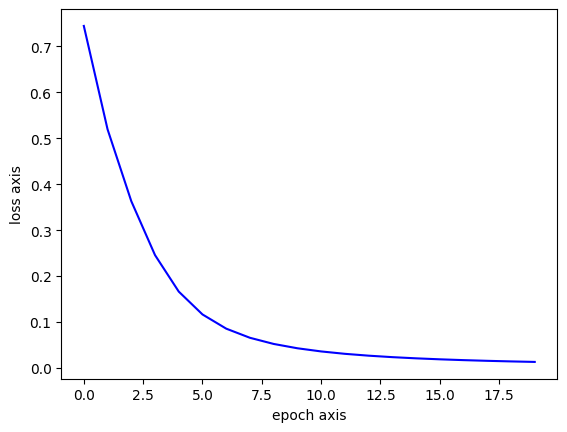

In [ ]:
conv_weight = torch.tensor([[[[0.1, 0.2, 0.1],
               [0.0, 0.3, 0.0],
               [0.2, 0.1, 0.2]]]],dtype=torch.float32, requires_grad=True)

x = torch.tensor([[[[1, 2, 3, 0, 1],
           [0, 1, 2, 1, 0],
           [1, 0, 1, 2, 3],
           [2, 1, 0, 1, 2],
           [3, 2, 1, 0, 1]]]],dtype=torch.float32)

fc_weight = torch.full([2, 1], 0.1, requires_grad=True) #展平了为1
fc_bias = torch.tensor([0.05, -0.05],dtype=torch.float32, requires_grad=True)
y_true_index = torch.tensor([1])

lr = 0.1

epochs = 20
criterion = nn.CrossEntropyLoss()
losses = []

for epoch in range(epochs):
  z_out = forward(conv_weight, fc_weight, fc_bias, x)
  y_pred = torch.softmax(z_out, dim=1)

  loss = criterion(z_out, y_true_index)
  losses.append(loss.item())

  loss.backward()

  with torch.no_grad():
    conv_weight -= lr * conv_weight.grad
    fc_weight -= lr * fc_weight.grad
    fc_bias -= lr * fc_bias.grad

  conv_weight.grad.zero_()
  fc_weight.grad.zero_()
  fc_bias.grad.zero_()

  if epoch %10 ==0:
    print(f"epoch: {epoch + 1}",
       f"loss: {loss.item():.4f}",
       f"z_out: {z_out.detach().round(decimals=4)}",
       f"conv_weight.grad: {conv_weight.grad.detach().round(decimals=4)}",
       f"fc_weight: {fc_weight.detach().round(decimals=4)}")

plt.plot(range(epochs), losses, "blue")
plt.xlabel("epoch axis")
plt.ylabel("loss axis")
plt.show()